In [6]:
import pandas as pd
import numpy as np

# Create a simple house price dataset
np.random.seed(42)

area = np.random.randint(600, 3500, 200)
bedrooms = np.random.randint(1, 5, 200)
age = np.random.randint(1, 30, 200)

# Price formula (simple but realistic)
price = (area * 150) + (bedrooms * 50000) - (age * 1000) + np.random.randint(-20000, 20000, 200)

df = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'price': price
})

df.head()


,area,bedrooms,age,price
0,1460,2,14,289000
1,1894,2,21,348152
2,1730,4,3,472006
3,1695,2,28,334324
4,2238,3,1,502855


In [7]:
df.to_csv("house_price.csv", index=False)


In [10]:
df = pd.read_csv("house_price.csv")
df.head()


,area,bedrooms,age,price
0,1460,2,14,289000
1,1894,2,21,348152
2,1730,4,3,472006
3,1695,2,28,334324
4,2238,3,1,502855


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      200 non-null    int64
 1   bedrooms  200 non-null    int64
 2   age       200 non-null    int64
 3   price     200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [12]:
df.describe()


,area,bedrooms,age,price
count,200.000000,200.000000,200.000000,200.000000
mean,2123.245000,2.655000,15.890000,436719.905000
std,795.601144,1.171682,8.747025,128749.172164
min,621.000000,1.000000,1.000000,135016.000000
25%,1468.250000,2.000000,8.000000,342361.750000
50%,2095.500000,3.000000,17.000000,436799.000000
75%,2790.000000,4.000000,23.000000,531667.000000
max,3488.000000,4.000000,29.000000,702706.000000


In [13]:
df.isnull().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

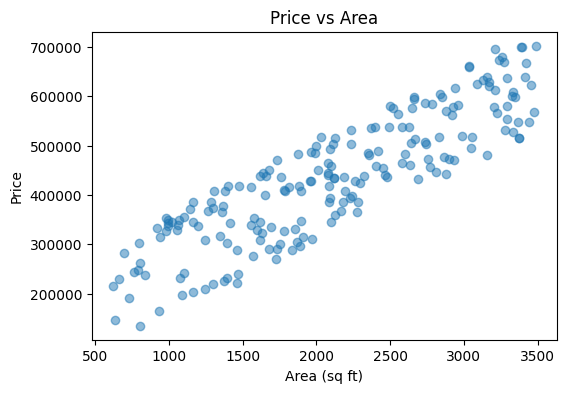

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df['area'], df['price'], alpha=0.5)
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Price vs Area")
plt.show()


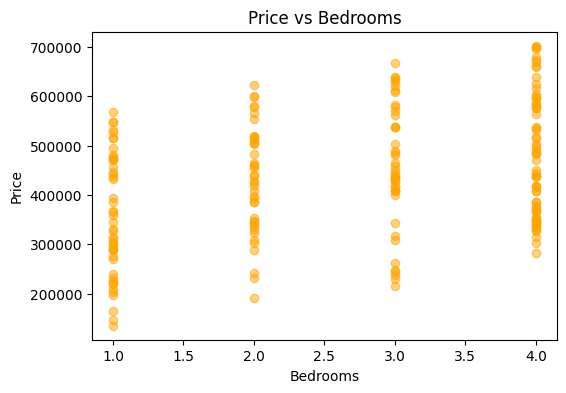

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(df['bedrooms'], df['price'], alpha=0.5, color='orange')
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Price vs Bedrooms")
plt.show()


In [16]:
X = df[['area', 'bedrooms', 'age']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head()


,Actual,Predicted
0,311781,324625.323601
1,503246,492104.829248
2,598102,595847.942094
3,578954,569947.238371
4,323685,328719.103717


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2


(9170.271089519068, 116389638.88907771, 0.9935670799346639)

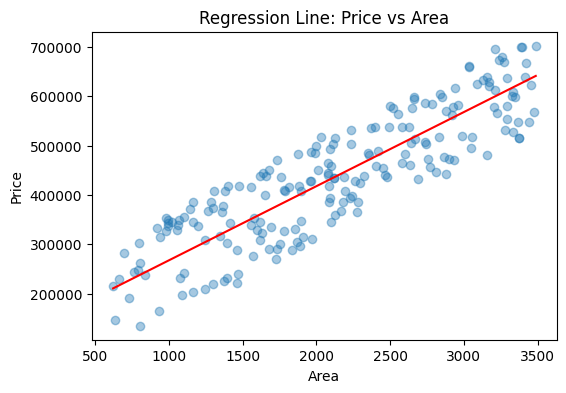

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df['area'], df['price'], alpha=0.4)

# Regression line
area_range = np.linspace(df['area'].min(), df['area'].max(), 100)
pred_line = model.predict(pd.DataFrame({
    'area': area_range,
    'bedrooms': np.full(100, df['bedrooms'].mean()),
    'age': np.full(100, df['age'].mean())
}))

plt.plot(area_range, pred_line, color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Regression Line: Price vs Area")
plt.show()


In [21]:
import joblib
joblib.dump(model, "house_price_model.pkl")


['house_price_model.pkl']

In [22]:
def predict_price(area, bedrooms, age):
    data = pd.DataFrame([[area, bedrooms, age]], columns=['area', 'bedrooms', 'age'])
    return model.predict(data)[0]

predict_price(1500, 3, 10)


np.float64(366724.9779242869)

## Conclusion

In this project, I built a Linear Regression model to predict house prices using features such as area, bedrooms, and age. After splitting the dataset into training and testing sets, the model was trained and evaluated using MAE, MSE, and R² score.

The scatter plots showed clear positive relationships between area and price, and between bedrooms and price. The regression line and residual plot confirmed that the model captures the trend reasonably well.

Finally, I saved the trained model using joblib and created a function that predicts house prices for new inputs. This completes the requirements of Task 2.
